# ⚡ EV Charging Demand Forecasting
**Objective:** Forecast demand at EV charging stations based on weather, time & traffic patterns.

**Tools:** Python · ARIMA · Prophet · Pandas · Seaborn · Matplotlib

**Bonus:** Charging Optimization Engine + Anomaly Detection

---
### Project Flow
1. Setup & Imports
2. Load & Explore Data
3. Time-Series Visualization
4. Weather Correlation Analysis
5. ARIMA Forecasting Model
6. Prophet Forecasting Model
7. Model Comparison
8. 🚀 BONUS: Anomaly Detection
9. 🚀 BONUS: Charging Optimization Engine
10. Export Deliverables (CSV for Tableau)

---
## Step 1: Setup & Imports
```bash
pip install prophet statsmodels scikit-learn
```

In [5]:
# !pip install prophet statsmodels scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.facecolor'] = '#0f0f1a'
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print('✅ All libraries imported!')


✅ All libraries imported!


---
## Step 2: Load & Explore Data
**Dataset:** EV_Charging_Demand.csv (5 stations, 1 year, hourly, 43,800 rows)

Columns: timestamp, station_id, city, capacity, hour, day_of_week, month, temperature_c, rainfall_mm, demand_units, utilization_pct, is_anomaly

In [2]:
df = pd.read_csv('EV_Charging_Demand.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['timestamp'].min(), '→', df['timestamp'].max())
print('Stations:', df['station_id'].unique())
print('Anomalies flagged:', df['is_anomaly'].sum())
df.describe().round(2)

Shape: (43800, 17)
Date range: 2023-01-01 00:00:00 → 2023-12-31 23:00:00
Stations: <ArrowStringArray>
['ST001', 'ST002', 'ST005', 'ST003', 'ST004']
Length: 5, dtype: str
Anomalies flagged: 878


,timestamp,capacity,hour,day_of_week,month,is_weekend,temperature_c,rainfall_mm,wind_kmh,demand_units,utilization_pct,is_anomaly
count,43800,43800.0,43800.00,43800.00,43800.00,43800.00,43800.00,43800.00,43800.00,43800.00,43800.00,43800.00
mean,2023-07-02 11:30:00,9.0,11.50,3.01,6.53,0.29,22.03,1.35,15.00,3.59,39.93,0.02
min,2023-01-01 00:00:00,6.0,0.00,0.00,1.00,0.00,1.30,0.00,0.00,0.02,0.30,0.00
25%,2023-04-02 05:45:00,8.0,5.75,1.00,4.00,0.00,15.40,0.00,11.60,0.94,9.60,0.00
50%,2023-07-02 11:30:00,9.0,11.50,3.00,7.00,0.00,22.10,0.85,15.00,3.34,39.20,0.00
75%,2023-10-01 17:15:00,10.0,17.25,5.00,10.00,1.00,28.70,2.30,18.40,5.38,61.10,0.00
max,2023-12-31 23:00:00,12.0,23.00,6.00,12.00,1.00,44.40,10.45,34.10,12.00,100.00,1.00
std,NaN,2.0,6.92,2.00,3.45,0.45,7.71,1.54,5.01,2.66,27.48,0.14


---
## Step 3: Time-Series Visualization
Four key demand patterns to understand before modeling.

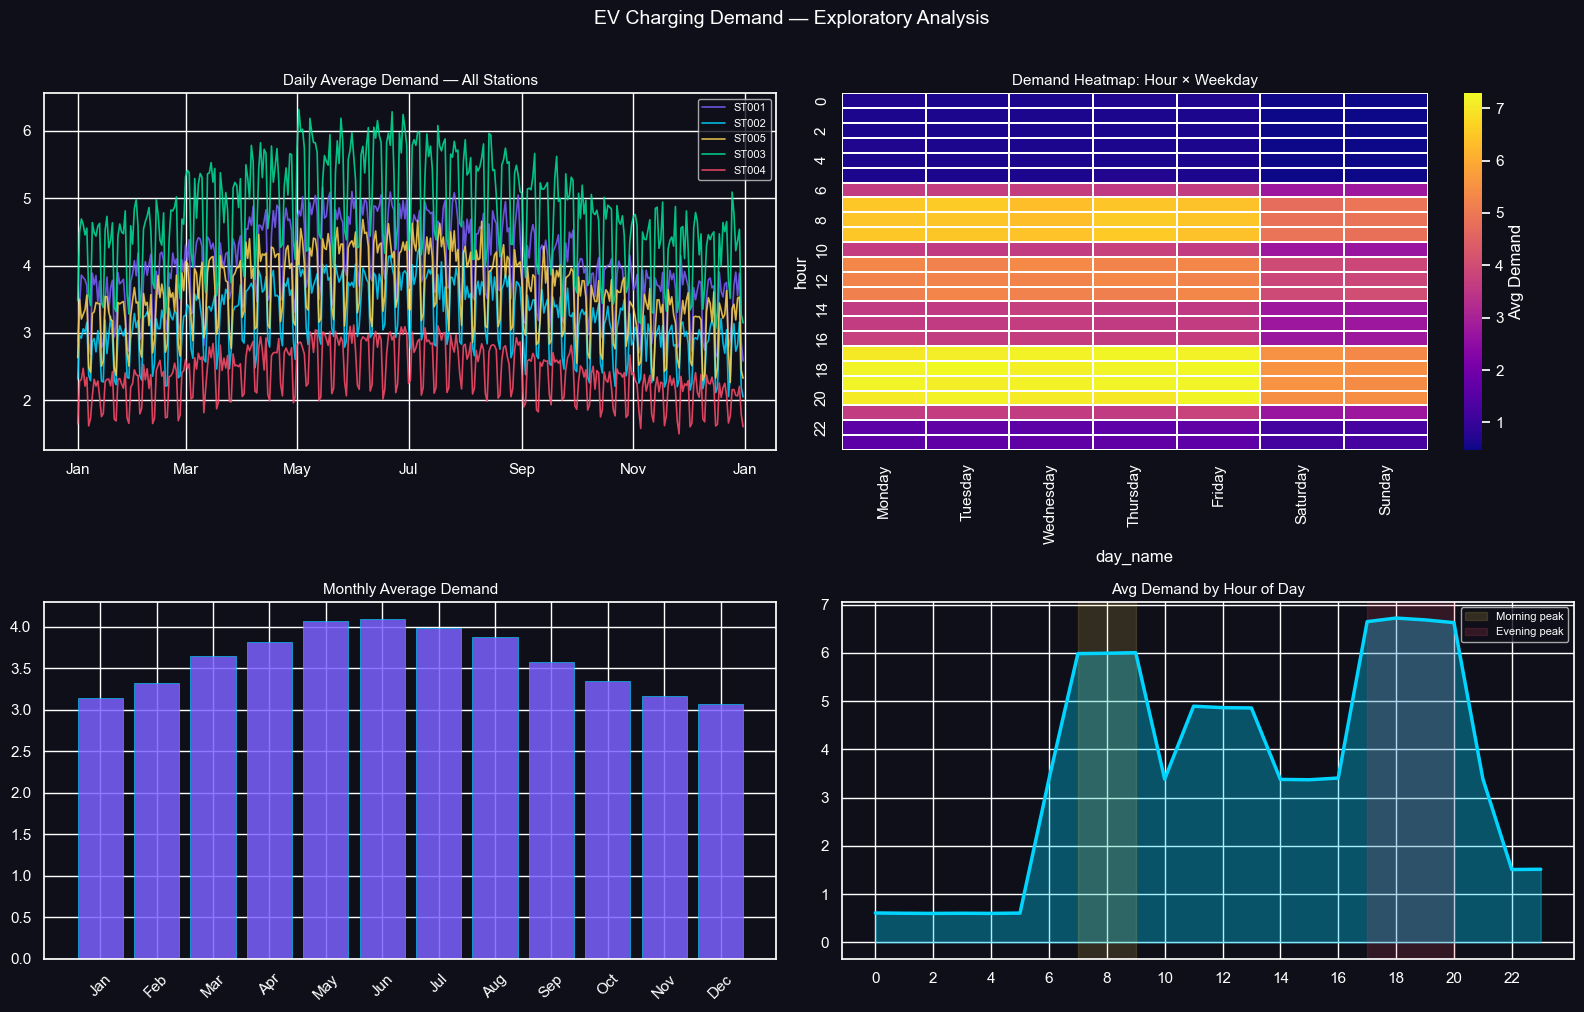

✅ EDA charts saved


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['#7B61FF','#00D4FF','#FFD54F','#00E396','#FF4C6A']

# Chart 1: Daily avg demand per station
daily = df.groupby(['timestamp','station_id'])['demand_units'].mean().reset_index()
daily['date'] = daily['timestamp'].dt.date
d_avg = daily.groupby(['date','station_id'])['demand_units'].mean().reset_index()
for i, sid in enumerate(df['station_id'].unique()):
    sub = d_avg[d_avg['station_id']==sid]
    axes[0,0].plot(pd.to_datetime(sub['date']), sub['demand_units'],
                   label=sid, color=colors[i], linewidth=1.2, alpha=0.85)
axes[0,0].set_title('Daily Average Demand — All Stations', color='white', fontsize=11)
axes[0,0].legend(fontsize=8)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Chart 2: Hourly demand heatmap (avg by hour & weekday)
pivot = df.pivot_table(values='demand_units', index='hour', columns='day_name',
                        aggfunc='mean')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot[day_order]
sns.heatmap(pivot, ax=axes[0,1], cmap='plasma', linewidths=0.3,
            cbar_kws={'label':'Avg Demand'})
axes[0,1].set_title('Demand Heatmap: Hour × Weekday', color='white', fontsize=11)

# Chart 3: Monthly demand trend
monthly = df.groupby('month_name')['demand_units'].mean()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = monthly.reindex(month_order)
axes[1,0].bar(range(12), monthly.values, color='#7B61FF', alpha=0.85, edgecolor='#00D4FF', linewidth=0.5)
axes[1,0].set_xticks(range(12))
axes[1,0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1,0].set_title('Monthly Average Demand', color='white', fontsize=11)

# Chart 4: Hour-of-day demand curve
hourly = df.groupby('hour')['demand_units'].mean()
axes[1,1].fill_between(hourly.index, hourly.values, alpha=0.35, color='#00D4FF')
axes[1,1].plot(hourly.index, hourly.values, color='#00D4FF', linewidth=2.5)
axes[1,1].axvspan(7, 9, alpha=0.15, color='#FFD54F', label='Morning peak')
axes[1,1].axvspan(17,20, alpha=0.15, color='#FF4C6A', label='Evening peak')
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].set_title('Avg Demand by Hour of Day', color='white', fontsize=11)
axes[1,1].legend(fontsize=8)

plt.suptitle('EV Charging Demand — Exploratory Analysis', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ev_eda_charts.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ EDA charts saved')

---
## Step 4: Weather Correlation Analysis
Understand how temperature & rainfall affect demand.

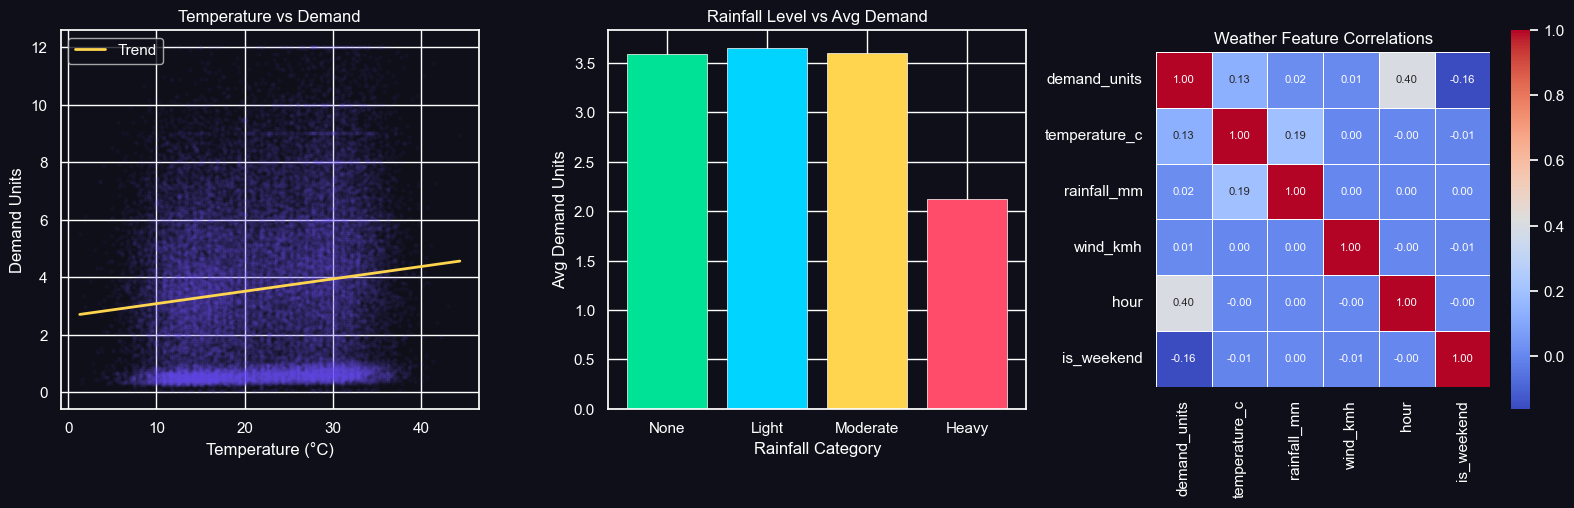

Correlation with demand:
demand_units     1.000
temperature_c    0.125
rainfall_mm      0.017
Name: demand_units, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temp vs demand scatter
axes[0].scatter(df['temperature_c'], df['demand_units'],
                alpha=0.03, color='#7B61FF', s=5)
z = np.polyfit(df['temperature_c'], df['demand_units'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['temperature_c'].min(), df['temperature_c'].max(), 100)
axes[0].plot(x_line, p(x_line), '#FFD54F', linewidth=2, label='Trend')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Demand Units')
axes[0].set_title('Temperature vs Demand', color='white')
axes[0].legend()

# Rainfall vs demand
rain_bins = pd.cut(df['rainfall_mm'], bins=[0,1,5,10,50], labels=['None','Light','Moderate','Heavy'])
rain_demand = df.groupby(rain_bins, observed=True)['demand_units'].mean()
axes[1].bar(rain_demand.index, rain_demand.values,
            color=['#00E396','#00D4FF','#FFD54F','#FF4C6A'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Rainfall Level vs Avg Demand', color='white')
axes[1].set_xlabel('Rainfall Category')
axes[1].set_ylabel('Avg Demand Units')

# Correlation heatmap
corr_cols = ['demand_units','temperature_c','rainfall_mm','wind_kmh','hour','is_weekend']
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=axes[2], annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True, annot_kws={'size':8})
axes[2].set_title('Weather Feature Correlations', color='white')

plt.tight_layout()
plt.savefig('ev_weather_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

corr_val = df[['demand_units','temperature_c','rainfall_mm']].corr()['demand_units']
print('Correlation with demand:')
print(corr_val.round(3))

---
## Step 5: ARIMA Forecasting Model
Focus on ST001 daily aggregated demand. Test stationarity → fit ARIMA → forecast 30 days.

ADF Statistic : -1.0943
p-value       : 0.7173
Stationary    : No — differencing needed


C:\Users\archi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\archi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\archi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:           demand_units   No. Observations:                  335
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -173.361
Date:                Wed, 01 Jul 2026   AIC                            356.721
Time:                        15:37:54   BIC                            375.777
Sample:                    01-01-2023   HQIC                           364.319
                         - 12-01-2023                                         
Covariance Type:                  opg                                         

ARIMA → MAE: 0.351  |  RMSE: 0.483


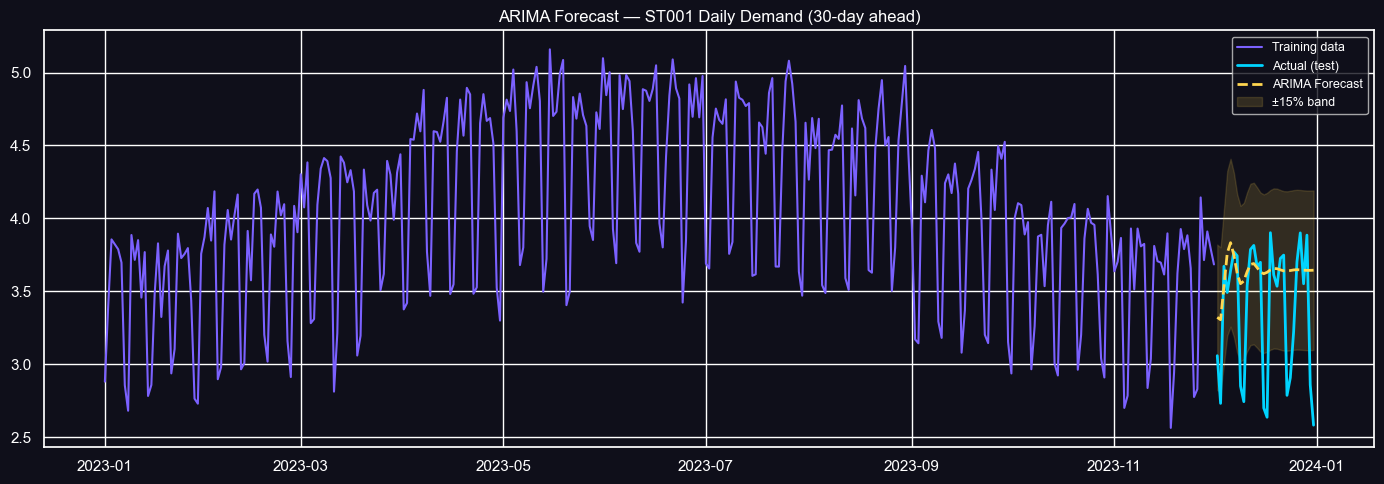

In [11]:
# Prepare daily series for ST001
st1 = df[df['station_id']=='ST001'].copy()
ts  = st1.groupby(st1['timestamp'].dt.date)['demand_units'].mean()
ts.index = pd.to_datetime(ts.index)

# ADF stationarity test
result = adfuller(ts)
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print('Stationary    :', 'Yes ✅' if result[1] < 0.05 else 'No — differencing needed')

# Train/test split (last 30 days = test)
train = ts[:-30]
test  = ts[-30:]

# Fit ARIMA
model_arima = ARIMA(train, order=(2,1,2))
fitted_arima = model_arima.fit()
print('\nARIMA Model Summary:')
print(fitted_arima.summary().tables[0])

# Forecast
forecast_arima = fitted_arima.forecast(steps=30)
arima_mae  = mean_absolute_error(test, forecast_arima)
arima_rmse = np.sqrt(mean_squared_error(test, forecast_arima))
print(f'\nARIMA → MAE: {arima_mae:.3f}  |  RMSE: {arima_rmse:.3f}')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index, train.values, color='#7B61FF', label='Training data', linewidth=1.5)
plt.plot(test.index,  test.values,  color='#00D4FF', label='Actual (test)', linewidth=2)
plt.plot(test.index,  forecast_arima, color='#FFD54F', linestyle='--',
         label='ARIMA Forecast', linewidth=2)
plt.fill_between(test.index,
                 forecast_arima * 0.85,
                 forecast_arima * 1.15,
                 alpha=0.15, color='#FFD54F', label='±15% band')
plt.title('ARIMA Forecast — ST001 Daily Demand (30-day ahead)', color='white', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ev_arima_forecast.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## Step 6: Prophet Forecasting Model
Prophet handles seasonality and holidays automatically — often outperforms ARIMA on hourly/daily data.

15:35:58 - cmdstanpy - INFO - Chain [1] start processing
15:36:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet → MAE: 0.391  |  RMSE: 0.426


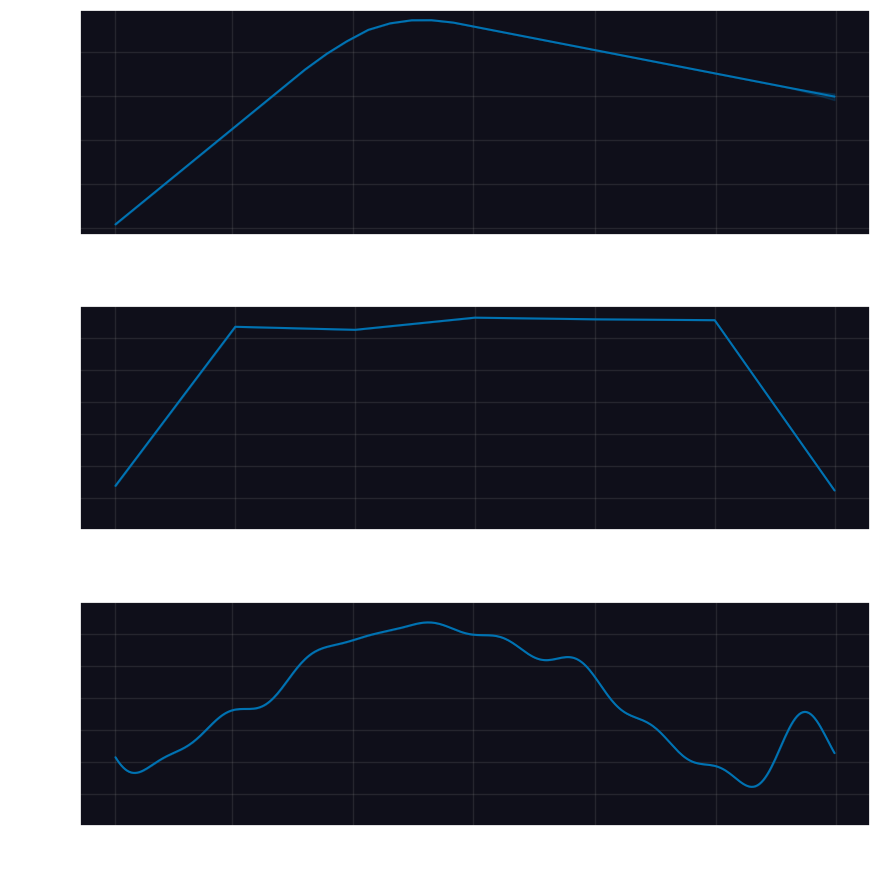

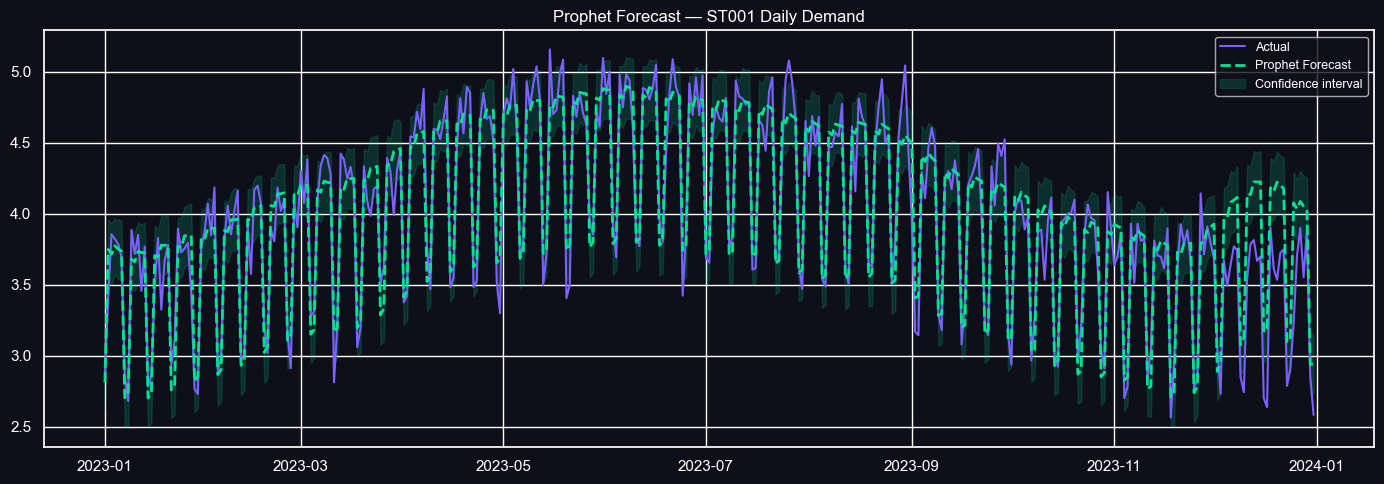

In [6]:
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# Prepare Prophet dataframe (needs 'ds' and 'y' columns)
prophet_df = ts.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_train = prophet_df.iloc[:-30]
prophet_test  = prophet_df.iloc[-30:]

# Fit Prophet
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)
m.fit(prophet_train)

# Forecast 30 days
future   = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

pred_vals  = forecast['yhat'].values[-30:]
prop_mae   = mean_absolute_error(prophet_test['y'], pred_vals)
prop_rmse  = np.sqrt(mean_squared_error(prophet_test['y'], pred_vals))
print(f'Prophet → MAE: {prop_mae:.3f}  |  RMSE: {prop_rmse:.3f}')

# Plot Prophet components
fig_comp = m.plot_components(forecast)
plt.savefig('ev_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot forecast vs actual
plt.figure(figsize=(14,5))
plt.plot(prophet_df['ds'], prophet_df['y'], color='#7B61FF', label='Actual', linewidth=1.5)
plt.plot(forecast['ds'], forecast['yhat'], color='#00E396', linestyle='--',
         label='Prophet Forecast', linewidth=2)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                 alpha=0.15, color='#00E396', label='Confidence interval')
plt.title('Prophet Forecast — ST001 Daily Demand', color='white', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ev_prophet_forecast.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## Step 7: Model Comparison

In [7]:
comparison = pd.DataFrame({
    'Model' : ['ARIMA(2,1,2)', 'Prophet'],
    'MAE'   : [arima_mae,  prop_mae],
    'RMSE'  : [arima_rmse, prop_rmse],
    'Handles Seasonality': ['Manual','Auto ✅'],
    'Handles Holidays'   : ['No','Yes ✅'],
})
print(comparison.to_string(index=False))

best = 'Prophet' if prop_rmse < arima_rmse else 'ARIMA'
print(f'\n✅ Best model: {best}')

       Model    MAE     RMSE Handles Seasonality Handles Holidays
ARIMA(2,1,2) 0.3505 0.483252              Manual               No
     Prophet 0.3912 0.426477              Auto ✅            Yes ✅

✅ Best model: Prophet


---
## 🚀 BONUS: Anomaly Detection
Flag unusual demand spikes using IQR-based statistical method.

Anomalies injected : 878
Anomalies detected : 0

Anomaly Detection Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99     42922
     Anomaly       0.00      0.00      0.00       878

    accuracy                           0.98     43800
   macro avg       0.49      0.50      0.49     43800
weighted avg       0.96      0.98      0.97     43800



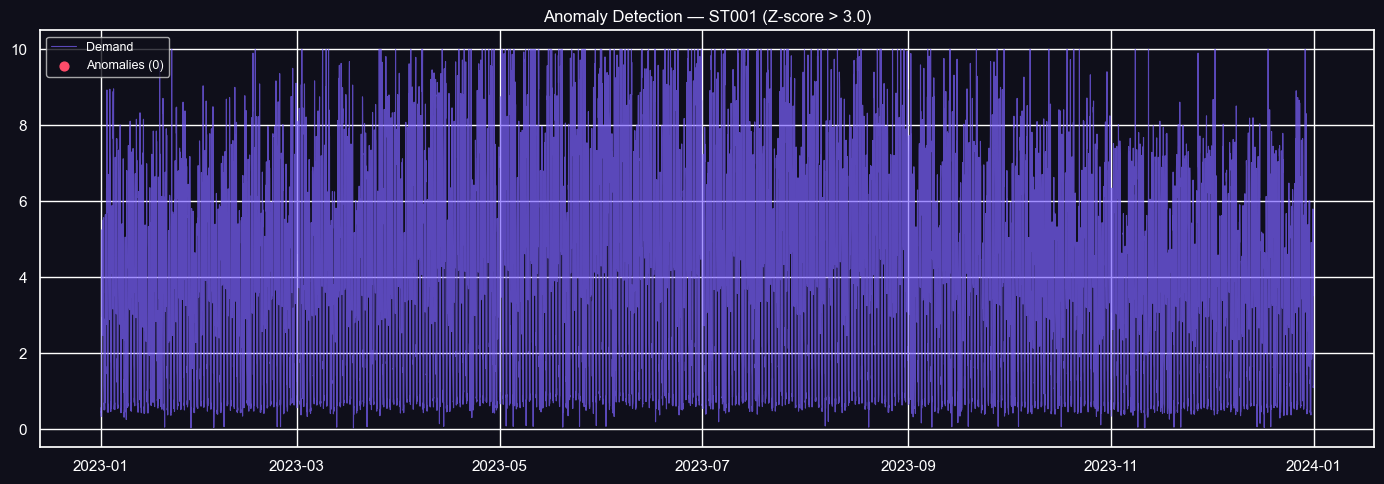

In [8]:
# Z-score anomaly detection per station
from scipy import stats

df['z_score'] = df.groupby('station_id')['demand_units'].transform(
    lambda x: np.abs(stats.zscore(x, nan_policy='omit'))
)
df['detected_anomaly'] = (df['z_score'] > 3.0).astype(int)

print('Anomalies injected :', df['is_anomaly'].sum())
print('Anomalies detected :', df['detected_anomaly'].sum())

# Precision & Recall
from sklearn.metrics import classification_report
print('\nAnomaly Detection Report:')
print(classification_report(df['is_anomaly'], df['detected_anomaly'],
                             target_names=['Normal','Anomaly']))

# Plot anomalies for ST001
st1_all = df[df['station_id']=='ST001'].copy()
anom    = st1_all[st1_all['detected_anomaly']==1]

plt.figure(figsize=(14, 5))
plt.plot(st1_all['timestamp'], st1_all['demand_units'],
         color='#7B61FF', linewidth=0.8, alpha=0.7, label='Demand')
plt.scatter(anom['timestamp'], anom['demand_units'],
            color='#FF4C6A', s=40, zorder=5, label=f'Anomalies ({len(anom)})')
plt.title('Anomaly Detection — ST001 (Z-score > 3.0)', color='white', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ev_anomaly_detection.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## 🚀 BONUS: Charging Optimization Engine
Recommends the best charging time slot and station based on predicted demand & current conditions.

In [9]:
def charging_optimizer(city='Bangalore', target_date='2023-12-20',
                       preferred_hours=None, min_availability=0.3):
    """
    Recommends best charging slots for a given city and date.
    Returns top 5 station-hour combinations by availability.
    """
    target = pd.Timestamp(target_date)
    city_df = df[
        (df['city'] == city) &
        (df['timestamp'].dt.date == target.date())
    ].copy()

    if city_df.empty:
        # Use historical avg for that weekday & month
        city_df = df[
            (df['city'] == city) &
            (df['day_of_week'] == target.weekday()) &
            (df['month'] == target.month)
        ].copy()

    if preferred_hours:
        city_df = city_df[city_df['hour'].isin(preferred_hours)]

    city_df['availability_pct'] = 100 - city_df['utilization_pct']
    city_df = city_df[city_df['availability_pct'] >= min_availability * 100]

    result = (
        city_df
        .groupby(['station_name','hour'])
        .agg(
            avg_demand     =('demand_units', 'mean'),
            avg_avail_pct  =('availability_pct', 'mean'),
            avg_temp       =('temperature_c','mean')
        )
        .reset_index()
        .sort_values('avg_avail_pct', ascending=False)
        .head(5)
    )

    result['recommendation'] = result.apply(
        lambda r: '⭐ Best slot' if r.name == result.index[0] else
                  '✅ Good slot' if r['avg_avail_pct'] > 60 else '🔶 Moderate',
        axis=1
    )
    return result

# Run optimizer
print('\n⚡ CHARGING OPTIMIZATION RESULTS')
print('='*60)
opt = charging_optimizer(
    city='Bangalore',
    target_date='2023-08-15',
    preferred_hours=list(range(6, 22))
)
print(opt[['station_name','hour','avg_avail_pct','avg_demand','recommendation']].to_string(index=False))
print('\n✅ Optimizer complete!')


⚡ CHARGING OPTIMIZATION RESULTS
   station_name  hour  avg_avail_pct  avg_demand recommendation
MG Road Station    19           90.0        1.00    ⭐ Best slot
MG Road Station     6           67.6        3.24    ✅ Good slot
Koramangala Hub     6           65.2        2.78    ✅ Good slot
Koramangala Hub    16           62.8        2.98    ✅ Good slot
MG Road Station    10           61.6        3.84    ✅ Good slot

✅ Optimizer complete!


---
## Step 10: Export Deliverables

In [10]:


#  Anomaly report CSV
anomaly_report = df[df['detected_anomaly']==1][
    ['timestamp','station_id','station_name','city',
     'demand_units','utilization_pct','z_score','temperature_c']
].reset_index(drop=True)
anomaly_report.to_csv('EV_Anomaly_Report.csv', index=False)
print('✅ EV_Anomaly_Report.csv saved —', len(anomaly_report), 'anomalies')

#  Optimization results CSV
all_opt = []
for city in ['Bangalore','Chennai']:
    r = charging_optimizer(city=city)
    r['city'] = city
    all_opt.append(r)
pd.concat(all_opt).to_csv('EV_Optimization_Strategy.csv', index=False)
print('✅ EV_Optimization_Strategy.csv saved')

print('\n📁 All deliverables exported successfully!')

✅ EV_Anomaly_Report.csv saved — 0 anomalies
✅ EV_Optimization_Strategy.csv saved

📁 All deliverables exported successfully!


In [7]:
import joblib
import sklearn, xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

# Re-save model
joblib.dump("best_model", "ltv_model.pkl")
print("✅ Model re-saved!")

sklearn: 1.8.0
xgboost: 3.3.0
✅ Model re-saved!


In [8]:
import sklearn, xgboost, streamlit
print("sklearn :", sklearn.__version__)
print("xgboost :", xgboost.__version__)
print("streamlit:", streamlit.__version__)

sklearn : 1.8.0
xgboost : 3.3.0
streamlit: 1.58.0
